## Settings

### User settings

In [1]:
admin_id = "ITF2"
workdir = "/home/nejk/code/extreme_precip_exposure"

rerun = True  # Set to True to re-download data, False to skip existing files

### Setup of environment

In [2]:
import os
import zipfile
import cdsapi
import glob
from pathlib import Path
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from functools import partial
from tqdm.auto import tqdm
import regionmask

# Set working directory (adjust as needed)
os.chdir(workdir)
print(f"Working directory: {os.getcwd()}")

Working directory: /etc/ecmwf/nfs/dh2_home_a/nejk/code/extreme_precip_exposure


In [3]:
# Define data directories
data_dir = Path("./data")
cds_dir = data_dir / "c3s_atlas"
hist_dir = cds_dir / "historical"
proj_dir = cds_dir / "projections"
output_dir = data_dir / admin_id / "extreme_precip_exposure"

# Create directories if they don't exist
for directory in [cds_dir, hist_dir, proj_dir, output_dir]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"Data will be saved to: {cds_dir}")
print(f"Output files will be saved to: {output_dir}")

Data will be saved to: data/c3s_atlas
Output files will be saved to: data/ITF2/extreme_precip_exposure


### Setup region specifics

In [4]:
regions_dir = data_dir / 'regions'
nuts_shp = regions_dir / 'NUTS_RG_20M_2024_4326' / 'NUTS_RG_20M_2024_4326.shp'
nuts_gdf = gpd.read_file(nuts_shp)

# Select the region of interest
sel_gdf = nuts_gdf[nuts_gdf['NUTS_ID'] == admin_id]
print(f"Region: {sel_gdf['NUTS_NAME'].values[0]}")
print(f"NUTS ID: {admin_id}")
print(f"Country: {sel_gdf['CNTR_CODE'].values[0]}")
print(f"Bounding box: {sel_gdf.geometry.total_bounds}")

# Rounded bounding box for downloading data (lon_min, lat_min, lon_max, lat_max)
lon_min, lat_min, lon_max, lat_max = sel_gdf.geometry.total_bounds
lon_min = (np.floor(lon_min) -1)
lat_min = (np.floor(lat_min) -1)
lon_max = (np.ceil(lon_max) +1)
lat_max = (np.ceil(lat_max) +1)
bbox = [lon_min, lat_min, lon_max, lat_max]
print(f"Rounded bounding box for data download: {bbox}")

Region: Molise
NUTS ID: ITF2
Country: IT
Bounding box: [13.94103834 41.38256335 15.13817868 42.07005936]
Rounded bounding box for data download: [np.float64(12.0), np.float64(40.0), np.float64(17.0), np.float64(44.0)]


## Download Hazard Data

### Helper function to unzip downloaded data

The CDS API downloads data as zip files. We need a function to extract and rename the NetCDF files.

In [5]:
def unzip_cds_data(zipfile_path):
    """
    Unzip data downloaded from CDS and rename to .nc extension.
    
    Parameters:
    -----------
    zipfile_path : Path or str
        Path to the zip file to extract
    """
    zipfile_path = Path(zipfile_path)
    
    with zipfile.ZipFile(zipfile_path, 'r') as zip_ref:
        names = zip_ref.namelist()
        zip_ref.extractall(zipfile_path.parent)
        
        for name in names:
            if name.split(".")[-1] == "nc":
                # Rename the extracted file to match the zip filename
                nc_path = zipfile_path.with_suffix('.nc')
                os.rename(zipfile_path.parent / name, nc_path)
                print(f"  Extracted: {nc_path.name}")
            else:
                # Remove non-NetCDF files
                os.remove(zipfile_path.parent / name)
    
    # Remove the zip file after extraction
    os.remove(zipfile_path)
    print(f"  Removed: {zipfile_path.name}")

### Download historical climate model outputs

We'll download historical climate outputs (1970-2005); takes only 1–2 minutes.

In [6]:
# Download historical climate model outputs
print("Downloading historical data (1970-2005)...")
print("=" * 60)

# Create filename
hist_zipfile = hist_dir / f"daily_precip_monmax_1970_2005_{admin_id}.zip"
hist_ncfile = hist_zipfile.with_suffix('.nc')
            
if not rerun and hist_ncfile.exists():
    print(f"  File already exists, skipping: {hist_ncfile.name}")
else:
    dataset = "multi-origin-c3s-atlas"
    request = {
        "variable": ["monthly_maximum_1_day_precipitation"],
        "origin": "cordex_eur_11",
        "domain": "euro_cordex",
        "experiment": "historical",
        "bias_adjustment": "no_bias_adjustment",
        "period": "1970-2005",
        "area": [lat_max, lon_min, lat_min, lon_max], # N, W, S, E
    }
    try:
        client = cdsapi.Client()
        client.retrieve(dataset, request).download(str(hist_zipfile))
        unzip_cds_data(hist_zipfile)
        proj_files.append(hist_ncfile)
    except Exception as e:
        print(f"  Error downloading historical data: {e}")


2026-03-30 12:40:29,882 INFO [2025-09-24T09:00:00] Help shape the future of the C3S Atlas by letting us know how you use it (including the application, this dataset, the documentation and user tools), and whether there are any additions or improvements you would like to see in the future. Complete the [C3S Atlas User Survey](https://ec.europa.eu/eusurvey/runner/791fd0a8-6c85-0971-4360-b98b2c585843).
2026-03-30 12:40:29,882 INFO Request ID is f9829cfb-fdd8-4686-b443-6192c594f823
2026-03-30 12:40:30,056 INFO status has been updated to accepted
2026-03-30 12:40:51,144 INFO status has been updated to running
2026-03-30 12:41:45,345 INFO status has been updated to successful


c8c64918b30afb0ee79ae071a02e12c5.zip:   0%|          | 0.00/78.8M [00:00<?, ?B/s]

  Extracted: daily_precip_monmax_1970_2005_ITF2.nc
  Removed: daily_precip_monmax_1970_2005_ITF2.zip
  Error downloading historical data: name 'proj_files' is not defined


### Download projected climate model outputs

We'll download all available models for all RCPs available; takes about 5-6 minutes. You can adjust these lists based on your needs.

In [7]:
# Define projection scenarios to download
rcps = ["rcp_2_6","rcp_4_5", "rcp_8_5"]

In [8]:
# Download projection data
print("Downloading projection data (2006-2100)...")
print("=" * 60)

proj_files = []
download_count = 0
skip_count = 0
error_count = 0

for rcp in rcps:

    # Create filename
    proj_zipfile = proj_dir / f"daily_precip_monmax_{rcp}_2006_2100_{admin_id}.zip"
    proj_ncfile = proj_zipfile.with_suffix('.nc')
                
    # Skip if already downloaded
    if not rerun and proj_ncfile.exists():
        skip_count += 1
        proj_files.append(proj_ncfile)
        continue                  
            
    dataset = "multi-origin-c3s-atlas"
    request = {
        "variable": ["monthly_maximum_1_day_precipitation"],
        "origin": "cordex_eur_11",
        "experiment": rcp,
        "bias_adjustment": "no_bias_adjustment",
        "period": "2006-2100",
        "area": [lat_max, lon_min, lat_min, lon_max], # N, W, S, E
    }
                
    try:
        client = cdsapi.Client()
        client.retrieve(dataset, request).download(str(proj_zipfile))
        unzip_cds_data(proj_zipfile)
        proj_files.append(proj_ncfile)
        download_count += 1
    except Exception as e:
        error_count += 1
        print(f"  Error downloading projection data: {e}")
    

print("=" * 60)
print(f"Projection data download summary:")
print(f"  New downloads: {download_count}")
print(f"  Already existed: {skip_count}")
print(f"  Errors/unavailable: {error_count}")
print(f"  Total projection files: {len(proj_files)}")

2026-03-30 12:41:47,894 INFO [2025-09-24T09:00:00] Help shape the future of the C3S Atlas by letting us know how you use it (including the application, this dataset, the documentation and user tools), and whether there are any additions or improvements you would like to see in the future. Complete the [C3S Atlas User Survey](https://ec.europa.eu/eusurvey/runner/791fd0a8-6c85-0971-4360-b98b2c585843).
2026-03-30 12:41:47,895 INFO Request ID is 416bb5d1-d99e-4825-a751-a7eb5bcf5d0d
2026-03-30 12:41:48,023 INFO status has been updated to accepted
2026-03-30 12:42:01,346 INFO status has been updated to running
2026-03-30 12:43:03,185 INFO status has been updated to successful


a793eb88e87190dcafcfc8ee6ab576d1.zip:   0%|          | 0.00/70.9M [00:00<?, ?B/s]

2026-03-30 12:43:04,250 INFO [2025-09-24T09:00:00] Help shape the future of the C3S Atlas by letting us know how you use it (including the application, this dataset, the documentation and user tools), and whether there are any additions or improvements you would like to see in the future. Complete the [C3S Atlas User Survey](https://ec.europa.eu/eusurvey/runner/791fd0a8-6c85-0971-4360-b98b2c585843).
2026-03-30 12:43:04,250 INFO Request ID is cc4be027-fa7f-4e60-9930-d0755d483ffc
2026-03-30 12:43:04,281 INFO status has been updated to accepted


  Extracted: daily_precip_monmax_rcp_2_6_2006_2100_ITF2.nc
  Removed: daily_precip_monmax_rcp_2_6_2006_2100_ITF2.zip


2026-03-30 12:44:20,070 INFO status has been updated to running
2026-03-30 12:45:56,280 INFO status has been updated to successful


...

2026-03-30 12:45:57,507 INFO [2025-09-24T09:00:00] Help shape the future of the C3S Atlas by letting us know how you use it (including the application, this dataset, the documentation and user tools), and whether there are any additions or improvements you would like to see in the future. Complete the [C3S Atlas User Survey](https://ec.europa.eu/eusurvey/runner/791fd0a8-6c85-0971-4360-b98b2c585843).
2026-03-30 12:45:57,507 INFO Request ID is e97493da-ebb4-42c0-8729-b7a380845749
2026-03-30 12:45:57,543 INFO status has been updated to accepted


  Extracted: daily_precip_monmax_rcp_4_5_2006_2100_ITF2.nc
  Removed: daily_precip_monmax_rcp_4_5_2006_2100_ITF2.zip


2026-03-30 12:46:18,514 INFO status has been updated to running
2026-03-30 12:48:48,935 INFO status has been updated to successful


8e2a1680677fab4689f3499b8ccf673c.zip:   0%|          | 0.00/217M [00:00<?, ?B/s]

  Extracted: daily_precip_monmax_rcp_8_5_2006_2100_ITF2.nc
  Removed: daily_precip_monmax_rcp_8_5_2006_2100_ITF2.zip
Projection data download summary:
  New downloads: 3
  Already existed: 0
  Errors/unavailable: 0
  Total projection files: 3


## Process Hazard Data

### Create NUTS region mask

/usr/local/apps/python3/3.12.11-01/lib/python3.12/site-packages/gribapi/__init__.py:23: UserWarning: ecCodes 2.42.0 or higher is recommended. You are running version 2.31.0
  warnings.warn(



Number of grid points in the mask: 32


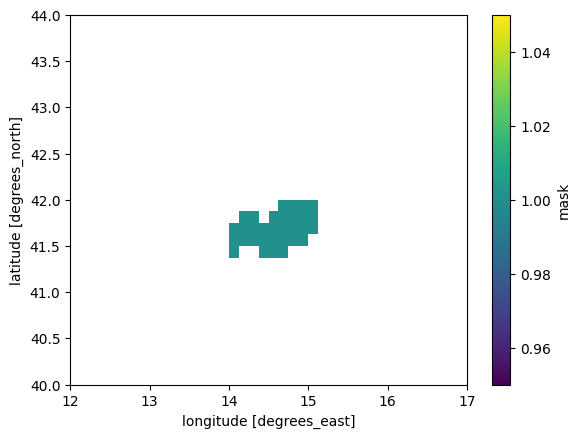

In [9]:
# Use regionmask to create a 2D mask for the NUTS region from sel_gdf geometry and with grid from the historical dataset
nuts_mask = regionmask.mask_geopandas(sel_gdf, xr.open_dataset(hist_dir / f"daily_precip_monmax_1970_2005_{admin_id}.nc"))
# reset index to np.nan/1
nuts_mask = xr.where(nuts_mask >= 1, 1, np.nan)
nuts_mask.plot()

# Number of grid points in the mask:
print(f"\nNumber of grid points in the mask: {np.sum(~np.isnan(nuts_mask.values))}")

### Process historical data
Now we'll read the historical data and extract information for our NUTS region. We'll save all grid point values as a csv for later processing, but also extract only the maximum per model and time step for a quick look.

#### Read and extract model information

In [10]:
# Read historical NetCDF file
hist_ncfile = hist_dir / f"daily_precip_monmax_1970_2005_{admin_id}.nc" 

if hist_ncfile.exists():
    # Open historical data
    precip_hist = xr.open_dataset(hist_ncfile)
    print("\nHistorical dataset:")
    print(precip_hist)

    # print all multi model ensemble members by gcm_model and rcm_model and ensemble member combinations and associate with member_id 
    mm_ensemble = precip_hist.groupby("member_id").groups.keys()
    print("\nMulti-model ensemble member:")
    i = 0
    for combo in mm_ensemble:
        print(combo) #  the member_id is defined as {gcm_institution}_{gcm_model}_{gcm_variant}_{rcm_institution}_{rcm_model}_{rcm_variant}
        #print(f"{precip_hist['gcm_institution'].values[i]}_{precip_hist['gcm_model'].values[i]}_{precip_hist['gcm_variant'].values[i]}_{precip_hist['rcm_institution'].values[i]}_{precip_hist['rcm_model'].values[i]}_{precip_hist['rcm_variant'].values[i]}")
        i += 1
else:
    print("Historical data file not found. Please download the data first.")

n_mmens = len(mm_ensemble)
print(f"\n {"-"*80} \n   * {n_mmens} multi-model ensemble members found in the historical dataset. \n {"-"*80} \n")


Historical dataset:
<xarray.Dataset> Size: 157MB
Dimensions:          (lat: 32, bnds: 2, lon: 40, time: 432, member: 71)
Coordinates:
  * lat              (lat) float64 256B 40.06 40.19 40.31 ... 43.69 43.81 43.94
  * lon              (lon) float64 320B 12.06 12.19 12.31 ... 16.69 16.81 16.94
  * time             (time) datetime64[ns] 3kB 1970-01-01 ... 2005-12-01
    member_id        (member) <U60 17kB ...
    gcm_institution  (member) <U12 3kB ...
    gcm_model        (member) <U12 3kB ...
    gcm_variant      (member) <U7 2kB ...
    rcm_institution  (member) <U10 3kB ...
    rcm_model        (member) <U17 5kB ...
    rcm_variant      (member) <U3 852B ...
Dimensions without coordinates: bnds, member
Data variables:
    lat_bnds         (lat, bnds) float64 512B ...
    lon_bnds         (lon, bnds) float64 640B ...
    time_bnds        (time, bnds) datetime64[ns] 7kB ...
    rx1day           (member, time, lat, lon) float32 157MB ...
    crs              int32 4B ...
Attributes: (12

#### Mask using NUTS region

In [11]:
# Extract data for NUTS region using regionmask
precip_hist_nuts = precip_hist.where(nuts_mask == 1, drop=True)
print(f"\nData for {admin_id}:")
print(precip_hist_nuts)

#precip_hist_nuts.isel(time=0).isel(member=0)['rx1day'].plot()
#precip_hist_nuts.isel(member=0)['rx1day'].max(dim=['lon','lat']).plot()


Data for ITF2:
<xarray.Dataset> Size: 6MB
Dimensions:          (lat: 5, bnds: 2, lon: 9, time: 432, member: 71)
Coordinates:
  * lat              (lat) float64 40B 41.44 41.56 41.69 41.81 41.94
  * lon              (lon) float64 72B 14.06 14.19 14.31 ... 14.81 14.94 15.06
  * time             (time) datetime64[ns] 3kB 1970-01-01 ... 2005-12-01
    member_id        (member) <U60 17kB 'CCCma_CanESM2_r1i1p1_CLMcom_CCLM4-8-...
    gcm_institution  (member) <U12 3kB ...
    gcm_model        (member) <U12 3kB ...
    gcm_variant      (member) <U7 2kB ...
    rcm_institution  (member) <U10 3kB ...
    rcm_model        (member) <U17 5kB ...
    rcm_variant      (member) <U3 852B ...
Dimensions without coordinates: bnds, member
Data variables:
    lat_bnds         (lat, bnds, lon) float64 720B 41.38 nan nan ... 42.0 42.0
    lon_bnds         (lon, bnds, lat) float64 720B 14.0 14.0 ... 15.12 15.12
    time_bnds        (time, bnds, lat, lon) datetime64[ns] 311kB 1970-01-01 ....
    rx1day       

#### Save all data as csv

In [12]:
# File 1: all data
# - convert xarray dataset precip_hist_nuts to a pandas dataframe
# - cleanup to save storage space and make it easier to work with for further analysis
# - save all lon/lat points in the NUTS region to a csv file with columns for time (format: YYYY-MM), member/member_id (but also rcm and gcm details, i.e. gcm_institution, gcm_model, gcm_variant, rcm_institution, rcm_model, rcm_variant), lon, lat, and rx1day
precip_hist_nuts_df = precip_hist_nuts.to_dataframe().reset_index()
precip_hist_nuts_df['time'] = precip_hist_nuts_df['time'].dt.strftime('%Y-%m')
precip_hist_nuts_df.drop(columns=['lon_bnds', 'lat_bnds', 'bnds', 'time_bnds', 'crs'], inplace=True) # remove some unnecessary columns
precip_hist_nuts_df.dropna(inplace=True) # drop all rows with missing values (i.e. points outside the NUTS region)
precip_hist_nuts_df['admin_id'] = admin_id
precip_hist_nuts_df.to_csv(f"{output_dir}/{admin_id}_precip_hist_all_points.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_hist_all_points.csv")

Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_hist_all_points.csv


#### Save annual max for all points and models as csv

In [13]:
# File 2: annual maximum and NUTS maximum of rx1day for each time step and member/member_id 
precip_hist_nuts_amax = precip_hist_nuts.groupby('time.year').max()
precip_hist_nuts_amax_df = precip_hist_nuts_amax.to_dataframe().reset_index()
precip_hist_nuts_amax_df.drop(columns=['lon_bnds', 'lat_bnds', 'bnds', 'time_bnds', 'crs'], inplace=True) # remove some unnecessary columns
precip_hist_nuts_amax_df['admin_id'] = admin_id
precip_hist_nuts_amax_df.to_csv(f"{output_dir}/{admin_id}_precip_hist_amax_allpoints.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_hist_amax_allpoints.csv")


Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_hist_amax_allpoints.csv


### Save sample data for tutorials

In [14]:
# Save monthly data for one member but for all grid points in NUTS region
imember = 0
precip_hist_nuts_df[precip_hist_nuts_df['member'] == imember].to_csv(f"{output_dir}/{admin_id}_precip_hist_sample_model.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_hist_sample_model.csv")

# Save just annual max of one member but for all grid points in NUTS region
imember = 0
precip_hist_nuts_amax_df[precip_hist_nuts_amax_df['member'] == imember].to_csv(f"{output_dir}/{admin_id}_precip_hist_amax_sample_model.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_hist_amax_sample_model.csv")

# Save just annual max one grid point (the one closest to the centroid of the NUTS region) but for all models
nuts_centroid = sel_gdf.geometry.centroid.values[0]
lon = precip_hist_nuts['lon'].values
lat = precip_hist_nuts['lat'].values
lon_idx = np.argmin(np.abs(lon - nuts_centroid.x))
lat_idx = np.argmin(np.abs(lat - nuts_centroid.y))
precip_hist_nuts_amax_df[(precip_hist_nuts_amax_df['lon'] == lon[lon_idx]) & (precip_hist_nuts_amax_df['lat'] == lat[lat_idx])].to_csv(f"{output_dir}/{admin_id}_precip_hist_amax_sample_gridpoint.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_hist_amax_sample_gridpoint.csv")

Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_hist_sample_model.csv
Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_hist_amax_sample_model.csv
Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_hist_amax_sample_gridpoint.csv


/etc/ecmwf/ssd/ssd1/jupyterhub/nejk-jupyterhub/tmpdirs/nejk.14747543/ipykernel_876396/3930379516.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  nuts_centroid = sel_gdf.geometry.centroid.values[0]


### Process projection data

We'll read all projection files and organize them by RCPs; again save all grid point values and extract only the maximum per model and time step.

#### Read data

In [15]:
# Load projection data for each RCP
projection_data = {}

for rcp in rcps:
    proj_ncfile = proj_dir / f"daily_precip_monmax_{rcp}_2006_2100_{admin_id}.nc"
   
    if proj_ncfile.exists():
        try:
            # Load dataset
            ds = xr.open_dataset(proj_ncfile)
            projection_data[rcp] = ds
        except Exception as e:
            print(f"Error loading {proj_ncfile}: {e}")

print(f"\nSuccessfully loaded {len(projection_data)} model combinations")

# Show example
if len(projection_data) > 0:
    example_key = list(projection_data.keys())[0]
    print(f"\nExample dataset ({example_key}):")
    print(projection_data[example_key])


Successfully loaded 3 model combinations

Example dataset (rcp_2_6):
<xarray.Dataset> Size: 140MB
Dimensions:          (lat: 32, bnds: 2, lon: 40, time: 1140, member: 24)
Coordinates:
  * lat              (lat) float64 256B 40.06 40.19 40.31 ... 43.69 43.81 43.94
  * lon              (lon) float64 320B 12.06 12.19 12.31 ... 16.69 16.81 16.94
  * time             (time) datetime64[ns] 9kB 2006-01-01 ... 2100-12-01
    member_id        (member) <U45 4kB ...
    gcm_institution  (member) <U12 1kB ...
    gcm_model        (member) <U10 960B ...
    gcm_variant      (member) <U7 672B ...
    rcm_institution  (member) <U7 672B ...
    rcm_model        (member) <U14 1kB ...
    rcm_variant      (member) <U3 288B ...
Dimensions without coordinates: bnds, member
Data variables:
    lat_bnds         (lat, bnds) float64 512B ...
    lon_bnds         (lon, bnds) float64 640B ...
    time_bnds        (time, bnds) datetime64[ns] 18kB ...
    rx1day           (member, time, lat, lon) float32 140MB .

#### Mask using NUTS region

In [16]:
precip_proj_nuts = {}

for rcp in rcps:
    precip_proj_nuts[rcp] = projection_data[rcp].where(nuts_mask == 1, drop=True)

#### Save all data as csv

In [17]:
# - convert xarray dataset precip_proj_nuts to a pandas dataframe, but include all rcp scenario as a column in the dataframe
# - cleanup to save storage space and make it easier to work with for further analysis
# - save all lon/lat points in the NUTS region to a csv file with columns for time (format: YYYY-MM), member/member_id (but also rcm and gcm details, i.e. gcm_institution, gcm_model, gcm_variant, rcm_institution, rcm_model, rcm_variant), lon, lat, and rx1day
precip_proj_nuts_df = pd.DataFrame()
for rcp in rcps:
    dummy = precip_proj_nuts[rcp].to_dataframe().reset_index()
    dummy['rcp'] = rcp
    precip_proj_nuts_df = pd.concat([precip_proj_nuts_df, dummy], ignore_index=True)
precip_proj_nuts_df['time'] = precip_proj_nuts_df['time'].dt.strftime('%Y-%m')
precip_proj_nuts_df.drop(columns=['lon_bnds', 'lat_bnds', 'bnds', 'time_bnds', 'crs'], inplace=True) # remove some unnecessary columns
precip_proj_nuts_df.dropna(inplace=True) # drop all rows with missing values (i.e. points outside the NUTS region)
precip_proj_nuts_df['admin_id'] = admin_id
precip_proj_nuts_df.to_csv(f"{output_dir}/{admin_id}_precip_proj_all_points.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_proj_all_points.csv")

Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_proj_all_points.csv


#### Save annual max as csv

In [20]:
# File 2: annual maximum
precip_proj_nuts_amax_df = pd.DataFrame()
for rcp in rcps:
    dummy = precip_proj_nuts[rcp].groupby('time.year').max().to_dataframe().reset_index()
    dummy['rcp'] = rcp
    precip_proj_nuts_amax_df = pd.concat([precip_proj_nuts_amax_df, dummy], ignore_index=True)
precip_proj_nuts_amax_df.drop(columns=['lon_bnds', 'lat_bnds', 'bnds', 'time_bnds', 'crs'], inplace=True) # remove some unnecessary columns
precip_proj_nuts_amax_df['admin_id'] = admin_id
precip_proj_nuts_amax_df.to_csv(f"{output_dir}/{admin_id}_precip_proj_amax.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_proj_amax.csv")

Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_proj_amax.csv


### Save sample data for tutorials

In [32]:
# Sample grid point; the one closest to the centroid of the NUTS region:
nuts_centroid = (
    sel_gdf.to_crs(epsg=3035)   # projected CRS for accurate centroid
    .geometry.centroid
    .to_crs(sel_gdf.crs)        # back to original CRS (lon/lat)
    .values[0]
)
lon = precip_proj_nuts[rcps[0]]['lon'].values
lat = precip_proj_nuts[rcps[0]]['lat'].values
lon_idx = np.argmin(np.abs(lon - nuts_centroid.x))
lat_idx = np.argmin(np.abs(lat - nuts_centroid.y))

# Save monthly data for one member and one grid point (the one closest to the centroid of the NUTS region)
imember = 0
precip_proj_nuts_df[(precip_proj_nuts_df['member'] == imember) & (precip_proj_nuts_df['lon'] == lon[lon_idx]) & (precip_proj_nuts_df['lat'] == lat[lat_idx])].to_csv(f"{output_dir}/{admin_id}_precip_proj_sample_model_gridpoint.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_proj_sample_model_gridpoint.csv")

# Save just annual max of one member but for all grid points in NUTS region
imember = 0
precip_proj_nuts_amax_df[precip_proj_nuts_amax_df['member'] == imember].to_csv(f"{output_dir}/{admin_id}_precip_proj_amax_sample_model.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_proj_amax_sample_model.csv")

# Save just annual max one grid point (the one closest to the centroid of the NUTS region) but for all models
precip_proj_nuts_amax_df[(precip_proj_nuts_amax_df['lon'] == lon[lon_idx]) & (precip_proj_nuts_amax_df['lat'] == lat[lat_idx])].to_csv(f"{output_dir}/{admin_id}_precip_proj_amax_sample_gridpoint.csv", index=False)
print(f"Written file: {output_dir}/{admin_id}_precip_proj_amax_sample_gridpoint.csv")

Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_proj_sample_model_gridpoint.csv
Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_proj_amax_sample_model.csv
Written file: data/ITF2/extreme_precip_exposure/ITF2_precip_proj_amax_sample_gridpoint.csv


### Output summary 

**Output files created:**
- `{admin_id}_precip_hist_all_points.csv` - Historical model outputs with monthly maximum of daily precipitation for all grid points within NUTS region with admin_id (1970-2005)
- `{admin_id}_precip_hist_amax.csv` - Historical model outputs with annual maximum of daily precipitation for all grid points within NUTS region with admin_id (1970-2005)
- `{admin_id}_precip_proj_all_points.csv` - Projected model outputs with monthly maximum of daily precipitation for all grid points within NUTS region with admin_id (2006-2100)
- `{admin_id}_precip_proj_amax.csv` - Projected model outputs with annual maximum of daily precipitation for all grid points within NUTS region with admin_id (2006-2100)
These CSV files can now be used for further analysis, risk assessment, or integration with exposure and vulnerability data.


In addition, we created the following **sample data** that is used in [the return period tutorial](../tutorials/return_period.ipynb):
- `{admin_id}_precip_hist_sample_model.csv` - Historical model output for one model/simulation for all grid points within NUTS region with admin_id (1970-2005)
- `{admin_id}_precip_hist_amax_sample_model.csv` - Historical model outputs for one model/simulation with annual maximum of daily precipitation for all grid points within NUTS region with admin_id (1970-2005)
- `{admin_id}_precip_hist_amax_sample_gridpoint.csv` - Historical model outputs for all model/simulation with annual maximum of daily precipitation for the closest gridpoint to centre of of the NUTS region with admin_id (1970-2005)
- `{admin_id}_precip_proj_sample_model.csv` - Projected model output for one model/simulation for all grid points within NUTS region with admin_id (2006-2100)
- `{admin_id}_precip_proj_amax_sample_model.csv` - Projected model outputs for one model/simulation with annual maximum of daily precipitation for all grid points within NUTS region with admin_id (2006-2100)
- `{admin_id}_precip_proj_amax_sample_gridpoint.csv` - Projected model outputs for all model/simulation with annual maximum of daily precipitation for the closest gridpoint to centre of of the NUTS region with admin_id (2006-2100)

If you want to continue now, why don't you move on to [the return period tutorial](../tutorials/return_period.ipynb)?